testing repairs generated from MTTF

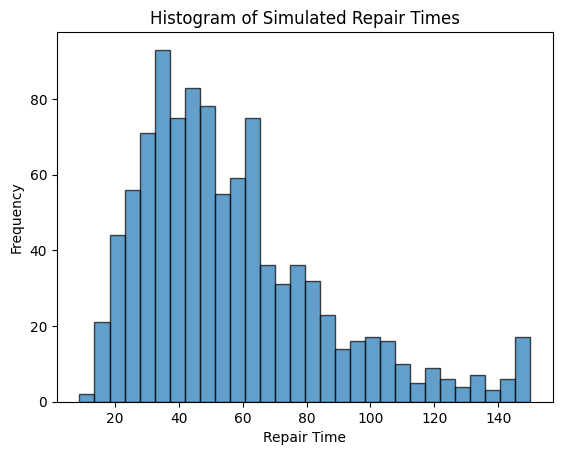

In [1]:
import numpy as np
import matplotlib.pyplot as plt

avg_repair_time =  50  # average repair time
n = 1000

# generate n random repair times based on exponential distribution
repair_times = np.zeros(n)
for i in range(n):
    time_until_repair = np.floor(np.random.lognormal(mean=np.log(avg_repair_time), sigma=0.5))

    # ensure the repair time is at least 1 and at most 3*avg_repair_time
    time_until_repair = max(1, min(time_until_repair, 3 * avg_repair_time))
    repair_times[i] = time_until_repair

# plot histogram of repair times
plt.hist(repair_times, bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of Simulated Repair Times')
plt.xlabel('Repair Time')
plt.ylabel('Frequency')
plt.show()


Initializing a Ship from Excel File
![](..\T-AO-system_diagrams.png)

initialize a ship and simulate it running and needing repairs

Total unrepairable failures due to lack of spares: 0
Total false failure alarms: 0


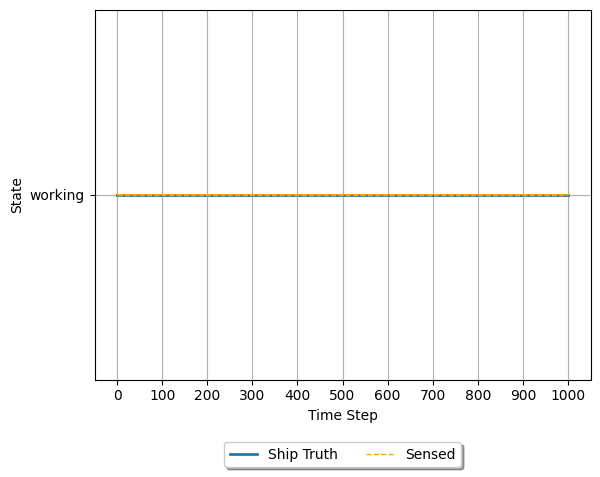

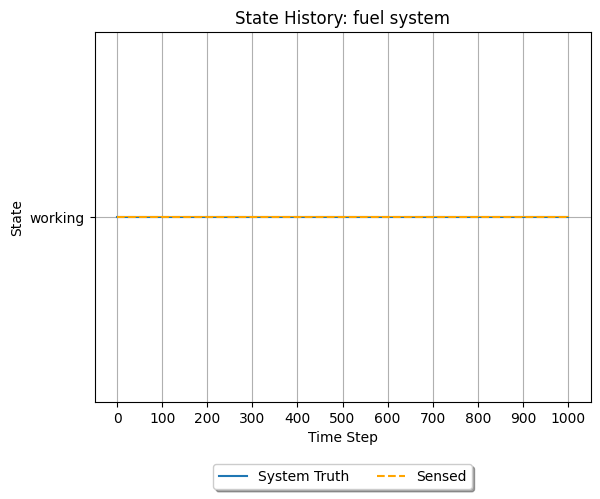

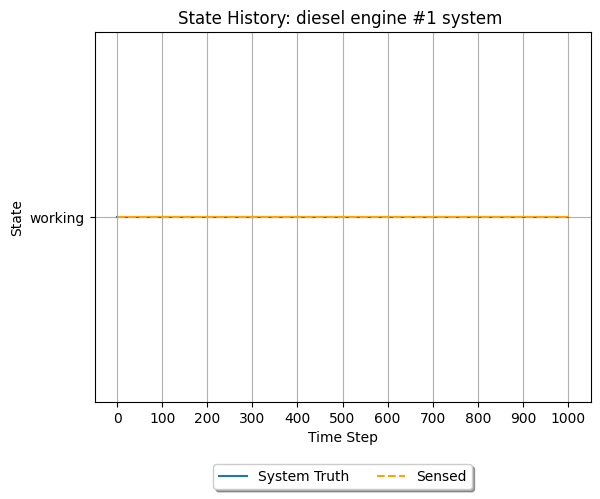

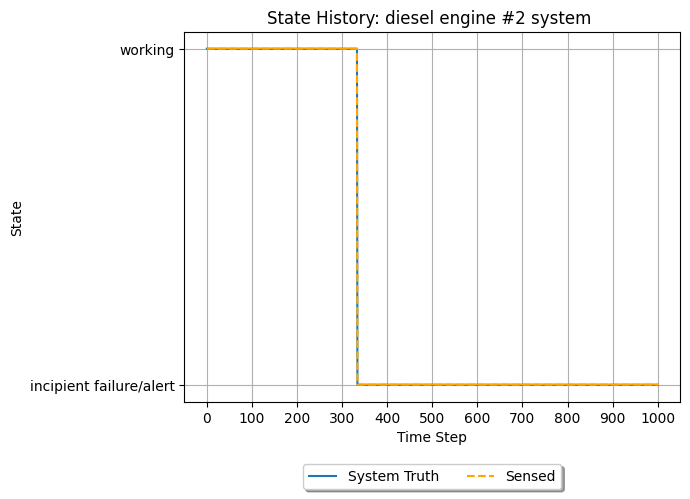

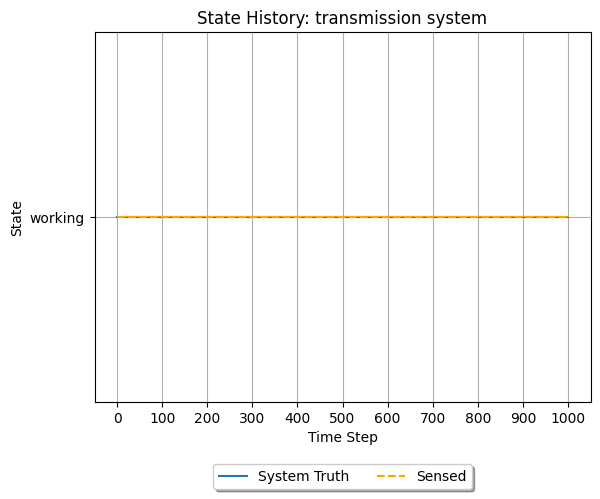

In [2]:
from shipClass.Ship import Ship
from shipClass.SensedShip import SensedShip

from shipClass.SimulateSensedShip import *

# initialize a test ship with 100% sensing accuracy
sensors = (3, 1.00) # (number of sensors, sensing accuracy percentage)
sensed_aux_ship = initialize_sensed_aux_ship(np_rng_num=4, sensors=sensors)

# simulate the ship operating for 720 hours with only 3 spare parts onboard
simulateWithSpareParts(sensed_aux_ship, time_steps=1000, number_of_spares=3)
sensed_aux_ship.plotHistory(plot_systems=True)

    #*** series comp object has no MTTR (use time_steps = 5000 to trigger error)

In [5]:
# checking sensors matrices

sensed_aux_ship.sensedSystems[1].sensedComps[0].printSensorMatrix()


# for system in sensed_aux_ship.sensedSystems:
#     for comp in system.sensedComps:
#         print(f"Component: {comp.name}, Sensor Matrix:\n{comp.sensor[1].sortensorMatrix}\n")


Component: Lube Oil Motor
Number of Sensors: 3
Sensor 1 (Quality: 1.0):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Sensor 2 (Quality: 1.0):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Sensor 3 (Quality: 1.0):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

